In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [6]:
# Load data
prices = pd.read_csv("data/raw/prices.csv", parse_dates=['Date'])
companies = pd.read_csv("data/raw/company_info.csv")
returns = pd.read_csv("data/raw/returns.csv", parse_dates=['Date'])


=== DATA SUMMARY ===
Prices: (36725, 7)
Companies: (25, 7)
Returns: (36700, 3)

Date range: 2019-01-02 00:00:00-05:00 to 2024-10-31 00:00:00-04:00
Tickers: 25

=== SECTORS ===
Sector
Communication Services    2
Consumer Cyclical         2
Consumer Defensive        3
Energy                    5
Financial Services        5
Healthcare                5
Technology                3
Name: Ticker, dtype: int64

=== SAMPLE DESCRIPTIONS ===
  Ticker                   Name  \
0   AAPL             Apple Inc.   
1   MSFT  Microsoft Corporation   
2  GOOGL          Alphabet Inc.   

                                         Description  
0  Apple Inc. designs, manufactures, and markets ...  
1  Microsoft Corporation develops and supports so...  
2  Alphabet Inc. offers various products and plat...  

✓ Saved validation plot


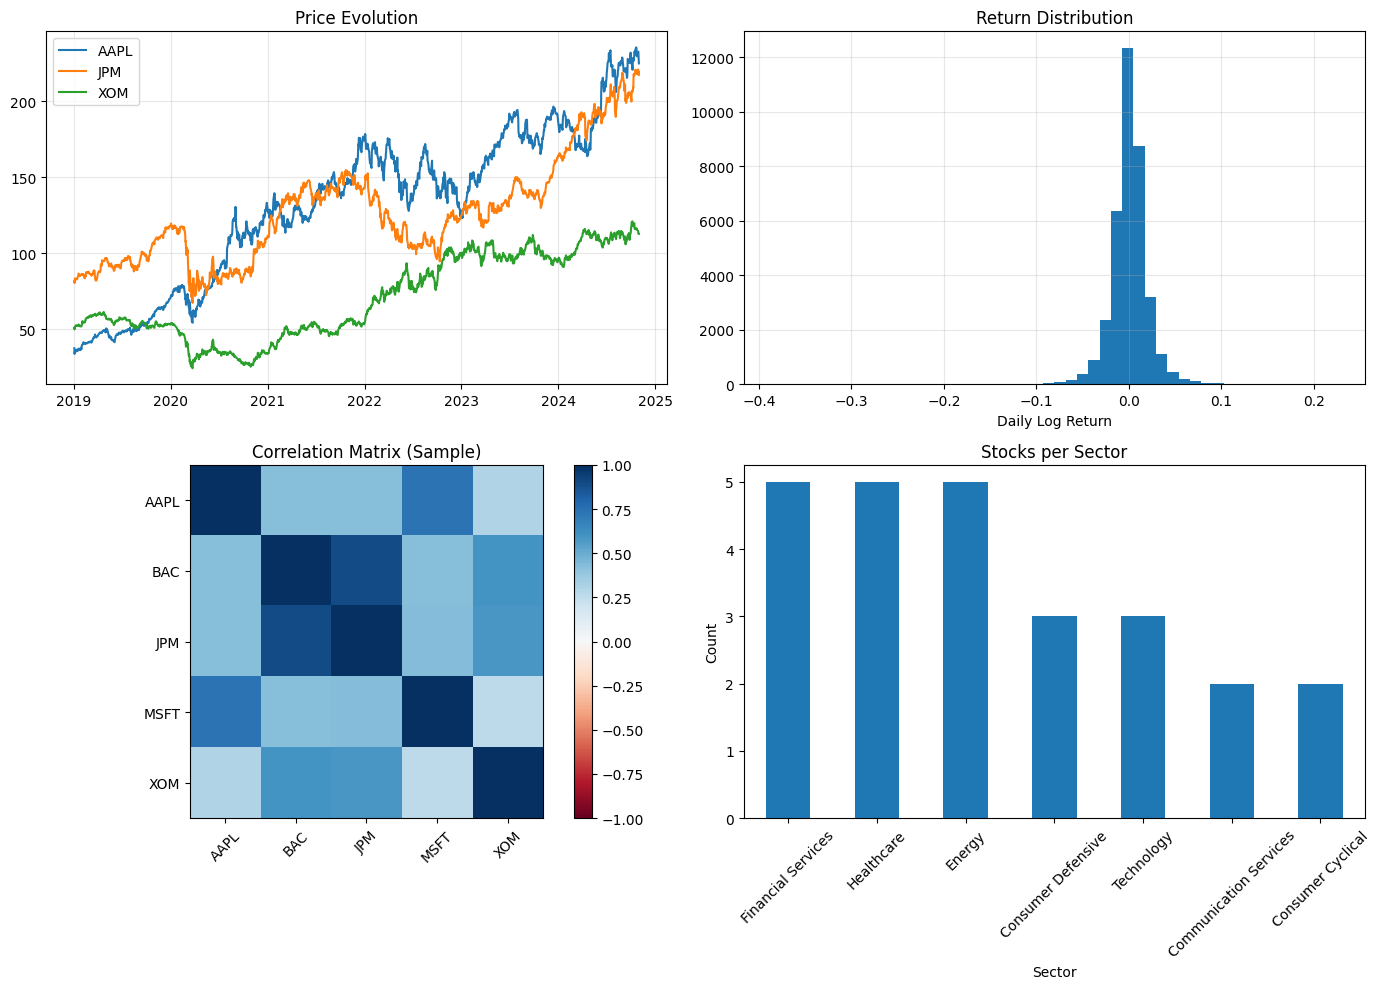

In [7]:
print("=== DATA SUMMARY ===")
print(f"Prices: {prices.shape}")
print(f"Companies: {companies.shape}")
print(f"Returns: {returns.shape}")
print(f"\nDate range: {prices['Date'].min()} to {prices['Date'].max()}")
print(f"Tickers: {prices['Ticker'].nunique()}")

# Show sectors
print("\n=== SECTORS ===")
print(companies.groupby('Sector')['Ticker'].count())

# Sample descriptions
print("\n=== SAMPLE DESCRIPTIONS ===")
print(companies[['Ticker', 'Name', 'Description']].head(3))

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price evolution
for ticker in ['AAPL', 'JPM', 'XOM']:
    data = prices[prices['Ticker'] == ticker]
    axes[0, 0].plot(data['Date'], data['Close'], label=ticker)
axes[0, 0].set_title('Price Evolution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Return distribution
returns['Return'].hist(bins=50, ax=axes[0, 1])
axes[0, 1].set_title('Return Distribution')
axes[0, 1].set_xlabel('Daily Log Return')
axes[0, 1].grid(True, alpha=0.3)

# Correlation heatmap (sample)
sample_tickers = ['AAPL', 'MSFT', 'JPM', 'BAC', 'XOM']
pivot = returns[returns['Ticker'].isin(sample_tickers)].pivot(
    index='Date', columns='Ticker', values='Return'
)
corr = pivot.corr()
im = axes[1, 0].imshow(corr, cmap='RdBu', vmin=-1, vmax=1)
axes[1, 0].set_xticks(range(len(corr)))
axes[1, 0].set_yticks(range(len(corr)))
axes[1, 0].set_xticklabels(corr.columns, rotation=45)
axes[1, 0].set_yticklabels(corr.columns)
axes[1, 0].set_title('Correlation Matrix (Sample)')
plt.colorbar(im, ax=axes[1, 0])

# Sector distribution
companies['Sector'].value_counts().plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Stocks per Sector')
axes[1, 1].set_xlabel('Sector')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('data/validation.png', dpi=150)
print("\n✓ Saved validation plot")